# 06 · ARIMA Time-Series Model on Daily Returns

Apply an **ARIMA** model to the S&P 500 daily log-return series. Steps: ADF stationarity test → ACF/PACF → model fitting → rolling forecast.

In [1]:
import sys, os
sys.path.insert(0, os.path.join(os.path.dirname(os.path.abspath('__file__')), '..'))
import config

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from sklearn.metrics import mean_absolute_error, mean_squared_error

sns.set_theme(style='whitegrid')
np.random.seed(config.RANDOM_STATE)
plt.rcParams.update({'figure.dpi': config.FIG_DPI})

## 1. Load Return Series

In [ ]:
df = pd.read_csv(
    config.PROCESSED_DATA_CSV,
    index_col='Date', parse_dates=True
)
series = df['LogReturn'].dropna()
print(f'Asset: {config.ASSET_NAME} ({config.ASSET_TICKER})')
print(f'Series length: {len(series):,}  ({series.index[0].date()} → {series.index[-1].date()})')

Series length: 3,893  (2010-01-29 → 2024-12-31)


## 2. Augmented Dickey-Fuller (ADF) Stationarity Test

In [3]:
def adf_test(series: pd.Series) -> dict:
    result = adfuller(series, autolag='AIC')
    return {
        'ADF statistic': result[0],
        'p-value':       result[1],
        'lags used':     result[2],
        'nobs':          result[3],
        **{f'Critical {k}': v for k, v in result[4].items()},
    }

adf_results = adf_test(series)
for k, v in adf_results.items():
    print(f'  {k:<20}: {v:.4f}')

if adf_results['p-value'] < 0.05:
    print('\n→ Series is STATIONARY (reject H₀ at 5%)')
else:
    print('\n→ Series is NON-STATIONARY (fail to reject H₀)')

  ADF statistic       : -60.3223
  p-value             : 0.0000
  lags used           : 0.0000
  nobs                : 3892.0000
  Critical 1%         : -3.4320
  Critical 5%         : -2.8623
  Critical 10%        : -2.5672

→ Series is STATIONARY (reject H₀ at 5%)


## 3. ACF & PACF Plots

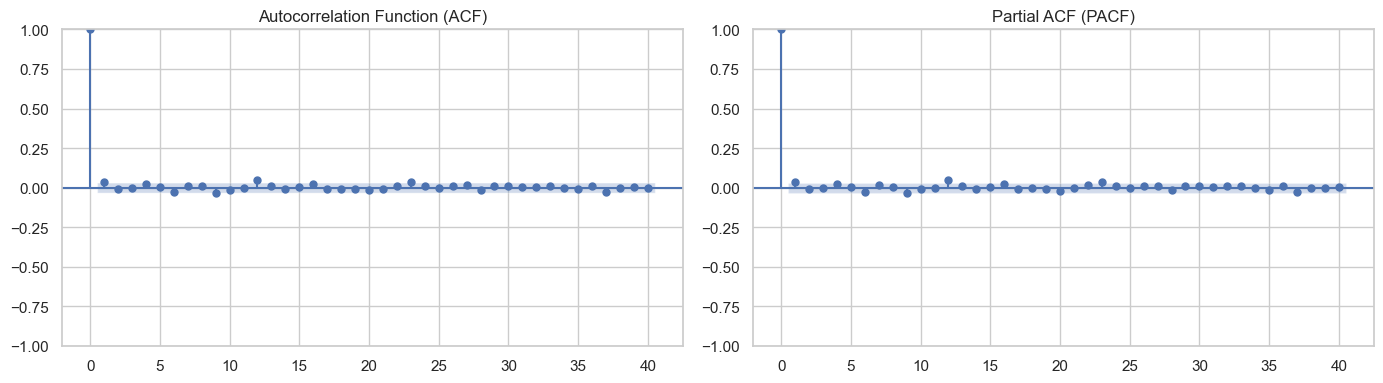

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
plot_acf(series,  lags=40, ax=axes[0], title='Autocorrelation Function (ACF)')
plot_pacf(series, lags=40, ax=axes[1], title='Partial ACF (PACF)', method='ywm')
plt.tight_layout()
plt.show()

## 4. Fit ARIMA Model

Order from `config.ARIMA_ORDER` = `(p, d, q)`.

In [5]:
order = config.ARIMA_ORDER
model = ARIMA(series, order=order).fit()
print(model.summary())

c:\Users\User\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency B will be used.
  self._init_dates(dates, freq)
c:\Users\User\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency B will be used.
  self._init_dates(dates, freq)
c:\Users\User\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency B will be used.
  self._init_dates(dates, freq)


                               SARIMAX Results                                
Dep. Variable:              LogReturn   No. Observations:                 3893
Model:                 ARIMA(1, 0, 1)   Log Likelihood               12025.929
Date:                Mon, 06 Apr 2026   AIC                         -24043.857
Time:                        10:24:27   BIC                         -24018.790
Sample:                    01-29-2010   HQIC                        -24034.959
                         - 12-31-2024                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0003      0.000      1.428      0.153   -9.65e-05       0.001
ar.L1         -0.2720      0.413     -0.659      0.510      -1.081       0.537
ma.L1          0.3059      0.408      0.750      0.4

## 5. In-Sample Fitted Values

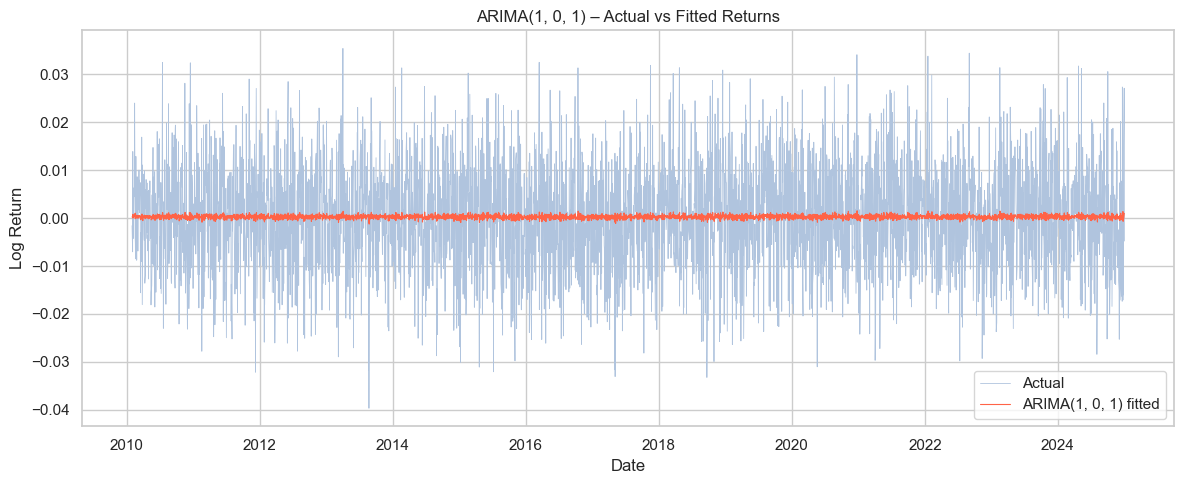

In [6]:
fitted = model.fittedvalues

fig, ax = plt.subplots(figsize=config.FIG_SIZE)
ax.plot(series.index, series, color='lightsteelblue', linewidth=0.6, label='Actual')
ax.plot(fitted.index, fitted, color='tomato', linewidth=0.8, label=f'ARIMA{order} fitted')
ax.set_title(f'ARIMA{order} – Actual vs Fitted Returns')
ax.set_xlabel('Date')
ax.set_ylabel('Log Return')
ax.legend()
plt.tight_layout()
plt.show()

## 6. Rolling One-Step-Ahead Forecast

Re-fit the model each step over the last `ARIMA_ROLLING_WINDOW` observations to produce out-of-sample one-day-ahead forecasts.

In [7]:
def rolling_arima_forecast(series: pd.Series, train_window: int,
                               n_forecast: int, order: tuple) -> pd.Series:
    """Walk-forward one-step ARIMA forecast.
    Uses a rolling training window of  and produces
     out-of-sample one-day-ahead predictions.
    """
    predictions = []
    dates = []
    series_arr = series.values
    start_idx = len(series_arr) - n_forecast

    for i in range(start_idx, len(series_arr)):
        train = series_arr[i - train_window: i]
        try:
            m = ARIMA(train, order=order).fit()
            fc = m.forecast(steps=1)[0]
        except Exception:
            fc = float('nan')
        predictions.append(fc)
        dates.append(series.index[i])

    return pd.Series(predictions, index=dates, name='Forecast')


train_window = config.ARIMA_ROLLING_WINDOW   # training window size
n_forecast   = 60                            # number of out-of-sample steps
print(f'Rolling forecast: {n_forecast} steps with {train_window}-day training window …')
forecasts = rolling_arima_forecast(series, train_window, n_forecast, order)
actuals   = series.loc[forecasts.index]

mae  = mean_absolute_error(actuals, forecasts)
rmse = mean_squared_error(actuals, forecasts) ** 0.5
print(f'Rolling Forecast MAE : {mae:.6f}')
print(f'Rolling Forecast RMSE: {rmse:.6f}')

Rolling forecast: 60 steps with 252-day training window …


c:\Users\User\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\User\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\User\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\User\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimizat

Rolling Forecast MAE : 0.010612
Rolling Forecast RMSE: 0.012570


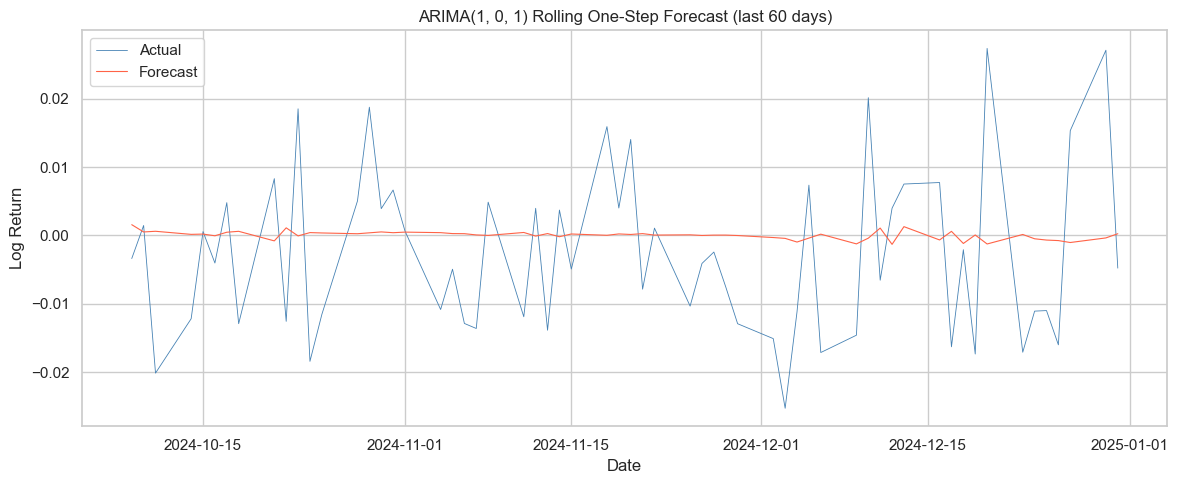

In [8]:
fig, ax = plt.subplots(figsize=config.FIG_SIZE)
ax.plot(actuals.index,   actuals,   color='steelblue', linewidth=0.6, label='Actual')
ax.plot(forecasts.index, forecasts, color='tomato',    linewidth=0.8, label='Forecast')
ax.set_title(f'ARIMA{order} Rolling One-Step Forecast (last {n_forecast} days)')
ax.set_xlabel('Date')
ax.set_ylabel('Log Return')
ax.legend()
plt.tight_layout()
plt.show()